# MidJourney Multiple Classes: FFT Mean + XGBoost / MLP

Notebook ini menjalankan eksperimen **multiple classes, single generator** untuk subset `MidJourney/train`. Task tetap biner: `AI vs nature`. Pada subset ini tersedia **4 kelas** yang seimbang pada kedua sisi, sehingga eksperimen bisa dijalankan langsung tanpa CLIP.

Model yang dibandingkan:
1. `XGBoost`
2. `MLP`

In [1]:
from pathlib import Path
import hashlib
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

PROJECT_ROOT = Path("..")
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "genimage" / "MidJourney" / "train"
IMAGENET_MAP = PROJECT_ROOT / "data" / "imagenet_class_index.json"
MANIFEST_OUT = PROJECT_ROOT / "data" / "genimage_manifest_midjourney_4class_train.csv"
FFT_OUT = PROJECT_ROOT / "artifacts" / "features_fft_mean_midjourney_4class_train.csv"
METRICS_OUT = PROJECT_ROOT / "artifacts" / "results_classification_midjourney_4class_fft_only.csv"
PRED_OUT = PROJECT_ROOT / "artifacts" / "predictions_classification_midjourney_4class_fft_only.csv"

print("Data root:", DATA_ROOT.resolve())
print("ImageNet map:", IMAGENET_MAP.resolve())

Data root: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/raw/genimage/MidJourney/train
ImageNet map: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/imagenet_class_index.json


## 1. Audit struktur subset

In [2]:
ai_dir = DATA_ROOT / "ai"
nature_dir = DATA_ROOT / "nature"
assert ai_dir.exists(), f"Folder tidak ditemukan: {ai_dir}"
assert nature_dir.exists(), f"Folder tidak ditemukan: {nature_dir}"

def is_valid_image_file(path: Path) -> bool:
    if not path.is_file():
        return False
    if ":Zone.Identifier" in path.name:
        return False
    return path.suffix.lower() in {".png", ".jpg", ".jpeg", ".webp", ".bmp"}

all_ai_files = sorted([p for p in ai_dir.iterdir() if p.is_file()])
all_nature_files = sorted([p for p in nature_dir.iterdir() if p.is_file()])
ai_files = sorted([p for p in all_ai_files if is_valid_image_file(p)])
nature_files = sorted([p for p in all_nature_files if is_valid_image_file(p)])

print("AI files (all):", len(all_ai_files))
print("Nature files (all):", len(all_nature_files))
print("AI valid image files:", len(ai_files))
print("Nature valid image files:", len(nature_files))
print("AI Zone.Identifier skipped:", sum(":Zone.Identifier" in p.name for p in all_ai_files))
print("Nature Zone.Identifier skipped:", sum(":Zone.Identifier" in p.name for p in all_nature_files))

AI files (all): 800
Nature files (all): 800
AI valid image files: 400
Nature valid image files: 400
AI Zone.Identifier skipped: 400
Nature Zone.Identifier skipped: 400


In [3]:
mapping = json.loads(IMAGENET_MAP.read_text())
idx_to_info = {int(k): tuple(v) for k, v in mapping.items()}
wnid_to_label = {v[0]: v[1] for v in mapping.values()}

ai_counts = {}
for p in ai_files:
    m = re.match(r"(\d{3})_", p.name)
    if m:
        key = int(m.group(1))
        ai_counts[key] = ai_counts.get(key, 0) + 1

nature_counts = {}
for p in nature_files:
    m = re.match(r"(n\d{8})_", p.name)
    if m:
        key = m.group(1)
        nature_counts[key] = nature_counts.get(key, 0) + 1

ai_summary = pd.DataFrame([
    {"class_idx": idx, "wnid": idx_to_info[idx][0], "label": idx_to_info[idx][1], "count": count}
    for idx, count in sorted(ai_counts.items())
])

nature_summary = pd.DataFrame([
    {"wnid": wnid, "label": wnid_to_label.get(wnid, "UNKNOWN"), "count": count}
    for wnid, count in sorted(nature_counts.items())
])

print("AI class summary:")
display(ai_summary)
print("Nature class summary:")
display(nature_summary)

print("Unique AI classes:", len(ai_summary))
print("Unique nature classes:", len(nature_summary))
assert len(ai_summary) == 4, "Eksperimen ini diasumsikan memakai 4 kelas AI."
assert len(nature_summary) == 4, "Eksperimen ini diasumsikan memakai 4 kelas nature."

AI class summary:


,class_idx,wnid,label,count
0,114,n01945685,slug,100
1,281,n02123045,tabby,100
2,654,n03769881,minibus,100
3,759,n04069434,reflex_camera,100


Nature class summary:


,wnid,label,count
0,n01945685,slug,100
1,n02123045,tabby,100
2,n03769881,minibus,100
3,n04069434,reflex_camera,100


Unique AI classes: 4
Unique nature classes: 4


## 2. Bangun manifest dari subset MidJourney 4 class

In [4]:
rows = []
for p in ai_files:
    image_id = "img_" + hashlib.sha1(str(p).encode("utf-8")).hexdigest()[:16]
    rows.append({
        "image_id": image_id,
        "path": str(p.resolve()),
        "relative_path": str(p.relative_to(DATA_ROOT)),
        "generator": "MidJourney",
        "subset_name": "midjourney_4class_train",
        "split": "train",
        "class_name": "ai",
        "content_id": p.name.split("_")[0],
        "is_real": 0,
        "y_ai": 1,
    })

for p in nature_files:
    m = re.match(r"(n\d{8})_", p.name)
    wnid = m.group(1) if m else "unknown"
    image_id = "img_" + hashlib.sha1(str(p).encode("utf-8")).hexdigest()[:16]
    rows.append({
        "image_id": image_id,
        "path": str(p.resolve()),
        "relative_path": str(p.relative_to(DATA_ROOT)),
        "generator": "MidJourney",
        "subset_name": "midjourney_4class_train",
        "split": "train",
        "class_name": "nature",
        "content_id": wnid,
        "is_real": 1,
        "y_ai": 0,
    })

manifest = pd.DataFrame(rows)
manifest.to_csv(MANIFEST_OUT, index=False)
print("Saved manifest:", MANIFEST_OUT.resolve())
print("Manifest shape:", manifest.shape)
display(manifest.head())

Saved manifest: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/data/genimage_manifest_midjourney_4class_train.csv
Manifest shape: (800, 10)


,image_id,path,relative_path,generator,subset_name,split,class_name,content_id,is_real,y_ai
0,img_b58784e07f2a8d30,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_midjourney_0.png,MidJourney,midjourney_4class_train,train,ai,114,0,1
1,img_6c2c6491f83585a2,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_midjourney_1.png,MidJourney,midjourney_4class_train,train,ai,114,0,1
2,img_dfea7e17d63244d9,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_midjourney_10.png,MidJourney,midjourney_4class_train,train,ai,114,0,1
3,img_cc9df89116d72148,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_midjourney_101.png,MidJourney,midjourney_4class_train,train,ai,114,0,1
4,img_a99d7f70adc0d961,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_midjourney_102.png,MidJourney,midjourney_4class_train,train,ai,114,0,1


## 3. Visualisasi sample image

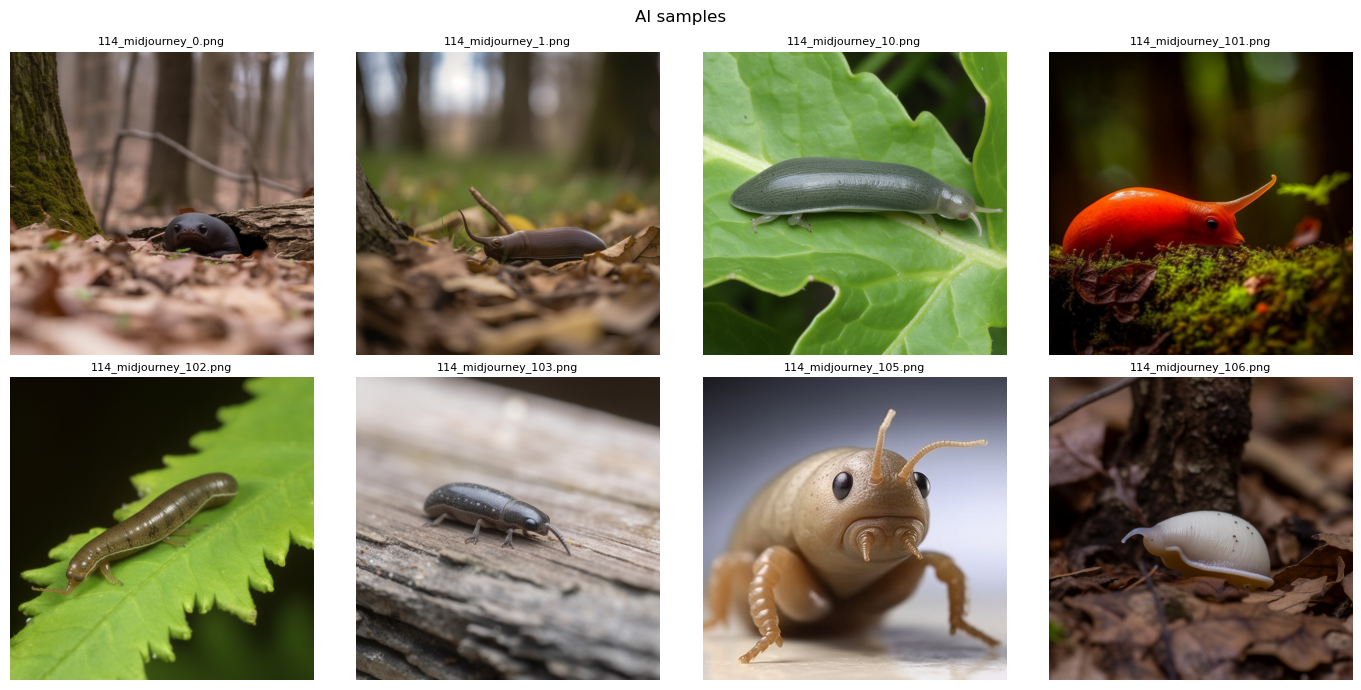

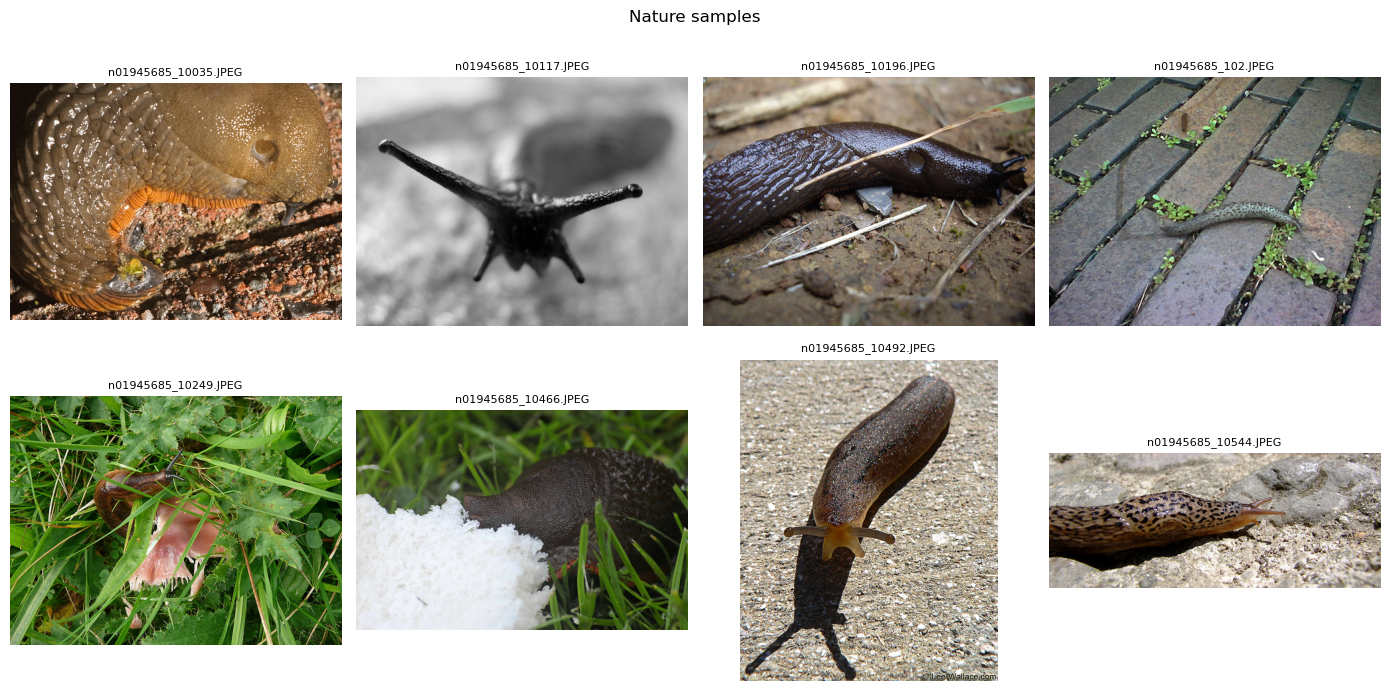

In [5]:
def show_grid(paths, title, ncols=4, figsize=(14, 7)):
    n = len(paths)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for ax, path in zip(axes, paths):
        img = Image.open(path).convert("RGB")
        ax.imshow(img)
        ax.set_title(Path(path).name, fontsize=8)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_grid(manifest[manifest["y_ai"] == 1]["path"].head(8).tolist(), "AI samples")
show_grid(manifest[manifest["y_ai"] == 0]["path"].head(8).tolist(), "Nature samples")

## 4. Hitung fitur FFT mean

In [6]:
def load_gray(path):
    return np.asarray(Image.open(path).convert("L"), dtype=np.float32)

def extract_fft_mean(gray):
    f = np.fft.fft2(gray)
    mag = np.abs(f)
    phase = np.angle(f)
    return {
        "fft_mag_mean": float(np.mean(mag)),
        "fft_phase_mean": float(np.mean(phase)),
        "fft_phase_cos_mean": float(np.mean(np.cos(phase))),
        "fft_phase_sin_mean": float(np.mean(np.sin(phase))),
    }

rows = []
for row in manifest.itertuples(index=False):
    gray = load_gray(row.path)
    feats = extract_fft_mean(gray)
    rows.append({"image_id": row.image_id, **feats})

fft_df = pd.DataFrame(rows)
fft_df.to_csv(FFT_OUT, index=False)
print("Saved FFT features:", FFT_OUT.resolve())
print("FFT shape:", fft_df.shape)
display(fft_df.head())

Saved FFT features: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/features_fft_mean_midjourney_4class_train.csv
FFT shape: (800, 5)


,image_id,fft_mag_mean,fft_phase_mean,fft_phase_cos_mean,fft_phase_sin_mean
0,img_b58784e07f2a8d30,6892.795898,0.000009,-0.009838,-9.313226e-10
1,img_6c2c6491f83585a2,4423.809570,0.000006,-0.003457,0.000000e+00
2,img_dfea7e17d63244d9,6951.932129,0.000009,0.005987,0.000000e+00
3,img_cc9df89116d72148,4233.602539,0.000006,0.000978,2.328306e-10
4,img_a99d7f70adc0d961,6513.393555,0.000009,-0.011808,0.000000e+00


## 5. Gabungkan manifest + fitur FFT

In [7]:
data = manifest.merge(fft_df, on="image_id", how="inner")
feature_cols = ["fft_mag_mean", "fft_phase_mean", "fft_phase_cos_mean", "fft_phase_sin_mean"]
print(data.shape)
display(data.head())
display(data.groupby("y_ai")[feature_cols].agg(["mean", "std"]))

(800, 14)


,image_id,path,relative_path,generator,subset_name,split,class_name,content_id,is_real,y_ai,fft_mag_mean,fft_phase_mean,fft_phase_cos_mean,fft_phase_sin_mean
0,img_b58784e07f2a8d30,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_midjourney_0.png,MidJourney,midjourney_4class_train,train,ai,114,0,1,6892.795898,0.000009,-0.009838,-9.313226e-10
1,img_6c2c6491f83585a2,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_midjourney_1.png,MidJourney,midjourney_4class_train,train,ai,114,0,1,4423.809570,0.000006,-0.003457,0.000000e+00
2,img_dfea7e17d63244d9,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_midjourney_10.png,MidJourney,midjourney_4class_train,train,ai,114,0,1,6951.932129,0.000009,0.005987,0.000000e+00
3,img_cc9df89116d72148,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_midjourney_101.png,MidJourney,midjourney_4class_train,train,ai,114,0,1,4233.602539,0.000006,0.000978,2.328306e-10
4,img_a99d7f70adc0d961,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai/114_midjourney_102.png,MidJourney,midjourney_4class_train,train,ai,114,0,1,6513.393555,0.000009,-0.011808,0.000000e+00


fft_mag_mean              fft_phase_mean           fft_phase_cos_mean  \
             mean          std           mean       std               mean   
y_ai                                                                         
0     7648.240306  3042.826462       0.000001  0.000020          -0.000084   
1     7609.048654  2896.663411       0.000007  0.000002          -0.000806   

               fft_phase_sin_mean                
           std               mean           std  
y_ai                                             
0     0.007894       1.177882e-11  4.095246e-10  
1     0.011058      -2.710294e-12  3.915703e-10

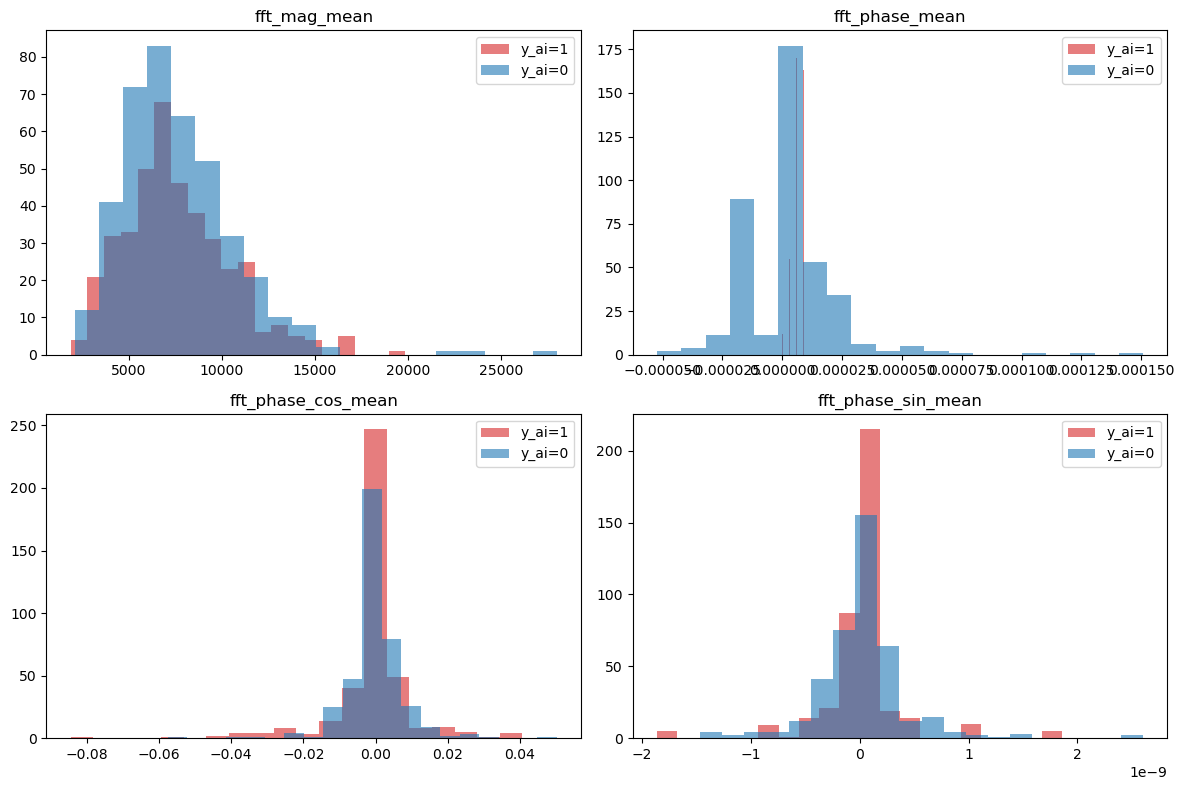

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for ax, col in zip(axes, feature_cols):
    for label, color in [(1, "tab:red"), (0, "tab:blue")]:
        ax.hist(data[data["y_ai"] == label][col], bins=20, alpha=0.6, label=f"y_ai={label}", color=color)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Split 80:20 dan train baseline

In [9]:
X = data[feature_cols].to_numpy(dtype=np.float32)
y = data["y_ai"].to_numpy(dtype=np.int64)

X_train, X_eval, y_train, y_eval, train_idx, eval_idx = train_test_split(
    X, y, data.index.to_numpy(), test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Eval:", X_eval.shape, y_eval.shape)

Train: (640, 4) (640,)
Eval: (160, 4) (160,)


In [10]:
models = {
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=42,
    ),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(hidden_layer_sizes=(64, 32), activation="relu", max_iter=500, random_state=42)),
    ]),
}

results = []
pred_store = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    score_ai = model.predict_proba(X_eval)[:, 1]
    pred_ai = (score_ai >= 0.5).astype(np.int64)
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_eval, pred_ai),
        "f1": f1_score(y_eval, pred_ai),
        "auroc": roc_auc_score(y_eval, score_ai),
    })
    pred_store[name] = {"score_ai": score_ai, "pred_ai": pred_ai}

results_df = pd.DataFrame(results).sort_values(by=["auroc", "f1", "accuracy"], ascending=False).reset_index(drop=True)
display(results_df)

,model,accuracy,f1,auroc
0,XGBoost,0.96250,0.962500,0.987500
1,MLP,0.95625,0.955975,0.976875


## 7. Confusion matrix model terbaik

Best model: XGBoost

              precision    recall  f1-score   support

      nature       0.96      0.96      0.96        80
          ai       0.96      0.96      0.96        80

    accuracy                           0.96       160
   macro avg       0.96      0.96      0.96       160
weighted avg       0.96      0.96      0.96       160



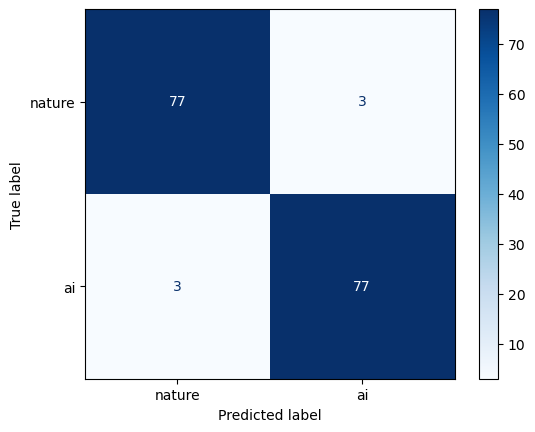

In [11]:
best_model = results_df.iloc[0]["model"]
print("Best model:", best_model)
print()
print(classification_report(y_eval, pred_store[best_model]["pred_ai"], target_names=["nature", "ai"]))
cm = confusion_matrix(y_eval, pred_store[best_model]["pred_ai"])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["nature", "ai"]).plot(cmap="Blues")
plt.show()

## 8. Simpan hasil

In [12]:
metrics_df = results_df.copy()
metrics_df["feature_set"] = "fft_mean_only"
metrics_df["split_protocol"] = "train_holdout_80_20"
metrics_df["subset_name"] = "midjourney_4class_train"
metrics_df["n_total"] = len(data)
metrics_df["n_train"] = len(X_train)
metrics_df["n_eval"] = len(X_eval)
metrics_df.to_csv(METRICS_OUT, index=False)

base_eval = data.iloc[eval_idx][["image_id", "path", "class_name", "content_id", "y_ai"]].copy()
pred_parts = []
for name, pred in pred_store.items():
    part = base_eval.copy()
    part["model"] = name
    part["score_ai"] = pred["score_ai"]
    part["pred_ai"] = pred["pred_ai"]
    pred_parts.append(part)

pred_df = pd.concat(pred_parts, ignore_index=True)
pred_df.to_csv(PRED_OUT, index=False)

print("Saved metrics:", METRICS_OUT.resolve())
print("Saved predictions:", PRED_OUT.resolve())
display(metrics_df)
display(pred_df.head())

Saved metrics: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/results_classification_midjourney_4class_fft_only.csv
Saved predictions: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/predictions_classification_midjourney_4class_fft_only.csv


,model,accuracy,f1,auroc,feature_set,split_protocol,subset_name,n_total,n_train,n_eval
0,XGBoost,0.96250,0.962500,0.987500,fft_mean_only,train_holdout_80_20,midjourney_4class_train,800,640,160
1,MLP,0.95625,0.955975,0.976875,fft_mean_only,train_holdout_80_20,midjourney_4class_train,800,640,160


,image_id,path,class_name,content_id,y_ai,model,score_ai,pred_ai
0,img_2d4d316c053905e1,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai,281,1,XGBoost,0.998155,1
1,img_d570a5a7ed165871,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,nature,n03769881,0,XGBoost,0.013791,0
2,img_53fda8db59ae7a4c,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,nature,n04069434,0,XGBoost,0.011484,0
3,img_93a527d99ed67889,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai,759,1,XGBoost,0.999070,1
4,img_3391f0ae5f3da89a,/home/nanda/folder belajar/TA-2026/nr_iqa_geni...,ai,654,1,XGBoost,0.973854,1


## 9. Catatan interpretasi
Notebook ini diposisikan sebagai eksperimen `multiple classes, single generator` untuk MidJourney, masih tanpa CLIP. Jika performanya tetap tinggi, itu memperkuat temuan bahwa `FFT mean` sendiri sudah cukup diskriminatif pada lebih dari satu generator.

In [13]:
# Sanity check: pastikan train dan eval benar-benar terpisah
train_ids = set(data.iloc[train_idx]["image_id"].tolist())
eval_ids = set(data.iloc[eval_idx]["image_id"].tolist())

overlap_ids = train_ids.intersection(eval_ids)

print("n_train_ids:", len(train_ids))
print("n_eval_ids:", len(eval_ids))
print("overlap_ids:", len(overlap_ids))

assert len(overlap_ids) == 0, "Ada image_id yang overlap antara train dan eval."

# Cek distribusi label train/eval
train_dist = data.iloc[train_idx]["y_ai"].value_counts().sort_index()
eval_dist = data.iloc[eval_idx]["y_ai"].value_counts().sort_index()

print("\nTrain label distribution:")
print(train_dist)

print("\nEval label distribution:")
print(eval_dist)

# Cek distribusi generator/content kalau mau lebih detail
if "generator" in data.columns:
    print("\nTrain generator x label:")
    display(
        data.iloc[train_idx]
        .groupby(["generator", "y_ai"])
        .size()
        .rename("count")
        .reset_index()
    )

    print("\nEval generator x label:")
    display(
        data.iloc[eval_idx]
        .groupby(["generator", "y_ai"])
        .size()
        .rename("count")
        .reset_index()
    )

if "content_id" in data.columns:
    print("\nTrain content_id x label:")
    display(
        data.iloc[train_idx]
        .groupby(["content_id", "y_ai"])
        .size()
        .rename("count")
        .reset_index()
        .sort_values(["content_id", "y_ai"])
    )

    print("\nEval content_id x label:")
    display(
        data.iloc[eval_idx]
        .groupby(["content_id", "y_ai"])
        .size()
        .rename("count")
        .reset_index()
        .sort_values(["content_id", "y_ai"])
    )


n_train_ids: 640
n_eval_ids: 160
overlap_ids: 0

Train label distribution:
y_ai
0    320
1    320
Name: count, dtype: int64

Eval label distribution:
y_ai
0    80
1    80
Name: count, dtype: int64

Train generator x label:


,generator,y_ai,count
0,MidJourney,0,320
1,MidJourney,1,320



Eval generator x label:


,generator,y_ai,count
0,MidJourney,0,80
1,MidJourney,1,80



Train content_id x label:


,content_id,y_ai,count
0,114,1,82
1,281,1,79
2,654,1,77
3,759,1,82
4,n01945685,0,81
5,n02123045,0,82
6,n03769881,0,80
7,n04069434,0,77



Eval content_id x label:


,content_id,y_ai,count
0,114,1,18
1,281,1,21
2,654,1,23
3,759,1,18
4,n01945685,0,19
5,n02123045,0,18
6,n03769881,0,20
7,n04069434,0,23
